### 🔹  Step 1: Importing Libraries, SQL Query, and Database Connection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sqlalchemy import create_engine

# Configuration de la connexion SQLAlchemy
driver = "ODBC Driver 17 for SQL Server"
server = "DESKTOP-CH9FCFH"
database = "DW_supplyChainProject"
username = "sa"
password = "sasa"

# Créer une connexion avec SQLAlchemy
engine = create_engine(f'mssql+pyodbc://{username}:{password}@{server}/{database}?driver={driver}')

# Requête SQL pour charger les données des ventes avec les informations de mois depuis Dim_Date
sales_data_query = """
SELECT 
    s.Product_Fk, 
    SUM(s.Product_Quantity_Sold) AS Total_Sold, 
    d.Month
FROM 
    Fact_Distribution_Sales s
JOIN 
    Dim_Date d ON s.Invoice_Date_Fk = d.Date_Pk
GROUP BY 
    s.Product_Fk,d.Month
"""
sales_data = pd.read_sql(sales_data_query, engine)

# Requête SQL pour charger les données du stockage
storage_data_query = """
SELECT 
    Product_Fk, 
    Product_Stored_Quantity 
FROM 
    Fact_Production_Storage
"""
storage_data = pd.read_sql(storage_data_query, engine)

# Fusionner les données des ventes et du stockage sur Product_Fk
merged_data = pd.merge(sales_data, storage_data, on='Product_Fk')
print(merged_data.head(20))


    Product_Fk  Total_Sold  Month  Product_Stored_Quantity
0          934          32     10                       95
1          934          32     10                       21
2          934          32     10                       80
3          934          32     10                       34
4          934          32     10                        3
5          934          32     10                       46
6          934          32     10                       17
7          934          32     10                       53
8          934          32     10                       44
9          934          32     10                      100
10         934          32     10                      100
11         934          32     10                        2
12         934          32     10                       45
13         934          32     10                       63
14         934          32     10                       31
15         934          32     10                       

### 🔹Step 2: Season Mapping Based on Month

In [2]:
# Mapping des saisons basé sur le mois
season_mapping = {
    '1': 'Hiver', '2': 'Hiver', '12': 'Hiver',
    '3': 'Printemps', '4': 'Printemps', '5': 'Printemps',
    '6': 'Été', '7': 'Été', '8': 'Été',
    '9': 'Automne', '10': 'Automne', '11': 'Automne'
}

# Ajouter la colonne 'Season' en utilisant le mois
merged_data['Season'] = merged_data['Month'].astype(str).map(season_mapping)

# Vérification du résultat
print(merged_data[['Month', 'Season']].head())


   Month   Season
0     10  Automne
1     10  Automne
2     10  Automne
3     10  Automne
4     10  Automne


 ### 🔹Step 3: Calculating Total Demand and Classifying Products by Demand Level

In [3]:
# Calculer la demande totale par produit
total_demand = merged_data.groupby('Product_Fk')['Total_Sold'].sum()

# Ajouter une colonne 'Demand_Class' : 'Forte' ou 'Faible' demande
mean_demand = total_demand.mean()
merged_data['Demand_Class'] = merged_data['Product_Fk'].map(lambda x: 'Forte' if total_demand[x] > mean_demand else 'Faible')

# Vérification du résultat
print(merged_data[['Product_Fk', 'Demand_Class']].head())


   Product_Fk Demand_Class
0         934        Forte
1         934        Forte
2         934        Forte
3         934        Forte
4         934        Forte


### 🔹 Step 4: Calculating Demand by Season and Identifying Seasonal Products

In [4]:
# Calculer la demande par saison
season_sales = merged_data.groupby(['Product_Fk', 'Season'])['Total_Sold'].sum().unstack(fill_value=0)

# Identifier les produits saisonniers : Si vente maximale dans une saison
season_sales['Is_Seasonal'] = season_sales.apply(lambda row: 1 if row.max() > row.mean() else 0, axis=1)

# Fusionner l'information des produits saisonniers avec merged_data
merged_data = merged_data.merge(season_sales[['Is_Seasonal']], on='Product_Fk', how='left')

# Vérification du résultat
print(merged_data[['Product_Fk', 'Is_Seasonal']].head())


   Product_Fk  Is_Seasonal
0         934            1
1         934            1
2         934            1
3         934            1
4         934            1


  ### 🔹 Step 5: Checking for Duplicate Rows and Identifying Redundancies

In [5]:

# Vérifier s'il y a des lignes redondantes (doublons)
duplicate_rows = merged_data[merged_data.duplicated()]

# Afficher les doublons s'il y en a
if not duplicate_rows.empty:
    print("Lignes redondantes détectées :")
    print(duplicate_rows)
else:
    print("Aucune ligne redondante détectée.")

# Si tu veux voir les doublons selon une ou plusieurs colonnes spécifiques (par exemple, Product_Fk et Month) :
duplicate_rows_specific = merged_data[merged_data.duplicated(subset=['Product_Fk', 'Month'])]

if not duplicate_rows_specific.empty:
    print("Doublons spécifiques détectés (basés sur Product_Fk et Month) :")
    print(duplicate_rows_specific)
else:
    print("Aucun doublon spécifique détecté.")

Lignes redondantes détectées :
        Product_Fk  Total_Sold  Month  Product_Stored_Quantity   Season  \
10             934          32     10                      100  Automne   
23             934          32     10                       53  Automne   
25             934          32     10                       95  Automne   
30             934          32     10                       38  Automne   
37             934          32     10                       89  Automne   
...            ...         ...    ...                      ...      ...   
222313        3899          40      6                       15      Été   
222314        3899          40      6                       92      Été   
222316        3899          40      6                       63      Été   
222318        3899          40      6                       85      Été   
222319        3899          40      6                       15      Été   

       Demand_Class  Is_Seasonal  
10            Forte            1 

#### 🔹 Step 6: Grouping and Aggregating Data by Sum for Product_Stored_Quantity

In [6]:
# Regrouper et agréger avec la somme pour Product_Stored_Quantity
merged_data_cleaned = merged_data.groupby(
    ['Product_Fk', 'Month', 'Total_Sold', 'Season', 'Demand_Class', 'Is_Seasonal']
).agg({
    'Product_Stored_Quantity': 'sum'
}).reset_index()

print("✅ Données après suppression des doublons logiques et agrégation par somme :")
print(merged_data_cleaned.head())


✅ Données après suppression des doublons logiques et agrégation par somme :
   Product_Fk  Month  Total_Sold     Season Demand_Class  Is_Seasonal  \
0         491      3          12  Printemps       Faible            1   
1         491      5           7  Printemps       Faible            1   
2         491      9          18    Automne       Faible            1   
3         491     10           7    Automne       Faible            1   
4         491     12          13      Hiver       Faible            1   

   Product_Stored_Quantity  
0                     1946  
1                     1946  
2                     1946  
3                     1946  
4                     1946  


 ### 🔹 Step 7 : Checking for Remaining Duplicates After Data Cleaning

In [7]:
# Vérifier l'absence de doublons après le nettoyage
duplicates_check = merged_data_cleaned.duplicated(
    subset=['Product_Fk', 'Month', 'Total_Sold', 'Season', 'Demand_Class', 'Is_Seasonal']
)

if duplicates_check.any():
    print("⚠️ Des doublons sont encore présents après le nettoyage.")
    print(merged_data_cleaned[duplicates_check])
else:
    print("✅ Aucun doublon trouvé après le nettoyage !")


✅ Aucun doublon trouvé après le nettoyage !


### 🔹 Step 8 :  Detecting Outliers in Numeric Columns (Total_Sold and Product_Stored_Quantity)

In [8]:
import numpy as np

# Colonnes numériques à vérifier
numeric_cols = ['Total_Sold', 'Product_Stored_Quantity']

# Dictionnaire pour stocker les outliers
outliers = {}

for col in numeric_cols:
    Q1 = merged_data_cleaned[col].quantile(0.25)
    Q3 = merged_data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_rows = merged_data_cleaned[
        (merged_data_cleaned[col] < lower_bound) | (merged_data_cleaned[col] > upper_bound)
    ]
    
    outliers[col] = outlier_rows
    print(f"\n📈 Valeurs aberrantes détectées dans '{col}': {len(outlier_rows)} lignes")
    if not outlier_rows.empty:
        print(outlier_rows[[col]].describe())

# Optionnel : Voir les lignes concernées par les outliers
# print(outliers['Total_Sold'])  # ou 'Product_Stored_Quantity'



📈 Valeurs aberrantes détectées dans 'Total_Sold': 304 lignes
       Total_Sold
count  304.000000
mean    39.115132
std      6.920332
min     33.000000
25%     34.000000
50%     37.000000
75%     41.000000
max     80.000000

📈 Valeurs aberrantes détectées dans 'Product_Stored_Quantity': 21 lignes
       Product_Stored_Quantity
count                21.000000
mean               2486.857143
std                 261.757576
min                1363.000000
25%                2515.000000
50%                2515.000000
75%                2523.000000
max                2624.000000


  ### 🔹 Step 9:Removing Outliers Using IQR for Numeric Columns

In [9]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"✅ {len(df) - len(cleaned_df)} valeurs aberrantes supprimées dans '{column}'")
    return cleaned_df

# Appliquer la suppression sur les deux colonnes
cleaned_data = remove_outliers_iqr(merged_data, 'Total_Sold')
cleaned_data = remove_outliers_iqr(cleaned_data, 'Product_Stored_Quantity')

# Vérifier le résultat
print(f"📊 Nombre final de lignes après suppression : {len(cleaned_data)}")


✅ 12160 valeurs aberrantes supprimées dans 'Total_Sold'
✅ 0 valeurs aberrantes supprimées dans 'Product_Stored_Quantity'
📊 Nombre final de lignes après suppression : 210160


  ### 🔹Step 10: Selecting Features and Normalizing Data for Clustering

In [10]:
# Sélectionner les caractéristiques pour le clustering
features = ['Total_Sold', 'Product_Stored_Quantity', 'Is_Seasonal']

# Normalisation des données
scaler = StandardScaler()
merged_data[features] = scaler.fit_transform(merged_data[features])

# Vérification des caractéristiques sélectionnées
print(merged_data[features].head())


   Total_Sold  Product_Stored_Quantity  Is_Seasonal
0    1.886813                 1.545223          0.0
1    1.886813                -0.986648          0.0
2    1.886813                 1.032006          0.0
3    1.886813                -0.541860          0.0
4    1.886813                -1.602509          0.0


  ### 🔹 step 11:Aplying the Elbow Method to Determine the Optimal Number of Clusters

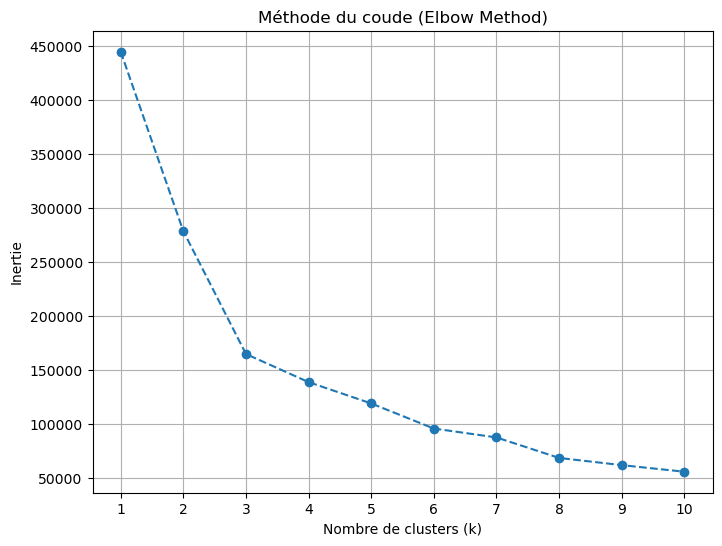

In [11]:
# Appliquer la méthode du coude pour déterminer le nombre optimal de clusters
inertia = []
k_range = range(1, 11)  # Tester les k de 1 à 10 clusters

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
    kmeans.fit(merged_data[features])
    inertia.append(kmeans.inertia_)  # Calculer l'inertie
# Tracer le graphique du coude
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Méthode du coude (Elbow Method)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.xticks(k_range)
plt.grid(True)
plt.show()

   ### 🔹Step 12: Applying KMeans to Create Clusters and Visualizing the Results

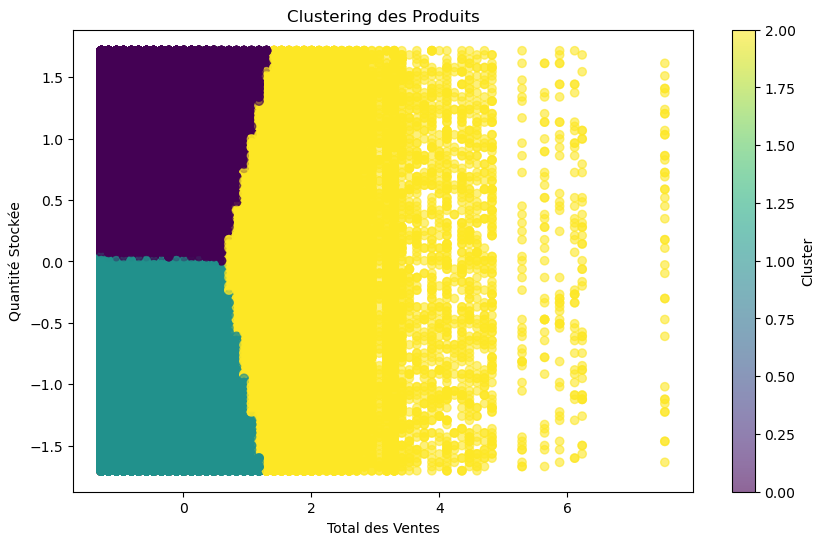

In [12]:
# Appliquer KMeans pour créer des clusters
kmeans = MiniBatchKMeans(n_clusters=3, random_state=42)
merged_data['Cluster'] = kmeans.fit_predict(merged_data[features])

#merged_data.to_csv('clustering_result.csv', index=False)

# Visualisation des clusters
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Total_Sold'], merged_data['Product_Stored_Quantity'], c=merged_data['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Clustering des Produits')
plt.xlabel('Total des Ventes')
plt.ylabel('Quantité Stockée')
plt.colorbar(label='Cluster')
plt.show()



In [13]:

# Détails des clusters : statistiques sur chaque cluster
for cluster_num in range(3):  # On suppose ici qu'il y a 3 clusters
    print(f"Cluster {cluster_num} - Détails :")
    cluster_data = merged_data[merged_data['Cluster'] == cluster_num]
    print(cluster_data[['Product_Fk', 'Total_Sold', 'Product_Stored_Quantity', 'Season']].describe())  # Statistiques


Cluster 0 - Détails :
         Product_Fk    Total_Sold  Product_Stored_Quantity
count  94945.000000  94945.000000             94945.000000
mean    2732.746474     -0.305097                 0.888668
std     1370.107030      0.597512                 0.494672
min      491.000000     -1.282465                 0.005572
25%     1525.000000     -0.812942                 0.450360
50%     2692.000000     -0.343420                 0.895148
75%     3926.000000      0.126103                 1.305722
max     5154.000000      1.299909                 1.716296
Cluster 1 - Détails :
         Product_Fk    Total_Sold  Product_Stored_Quantity
count  95889.000000  95889.000000             95889.000000
mean    2763.085828     -0.321614                -0.869017
std     1372.629225      0.585252                 0.503427
min      491.000000     -1.282465                -1.705152
25%     1545.000000     -0.812942                -1.294578
50%     2748.000000     -0.343420                -0.884005
75%     3962

In [ ]:
#Cluster 0: Products with low sales but generally in stock. This suggests overstocking issues.

#Cluster 1: Products with very low sales and negative stock values, indicating stock management problems leading to potential losses.

#Cluster 2: Products with strong sales performance, though with varied stock levels. This indicates good market performance but varying stock availability.


Cluster 0  
Nombre de Produits : 94,945  
Ventes (Total_Sold) :  
Moyenne : -0.30 (ventes faibles).  
Écart-type : 0.60, indiquant une certaine variabilité.  
Min/Max : Les ventes varient de -1.28 à 1.30.  
Stock (Product_Stored_Quantity) :  
Moyenne : 0.89, ce qui signifie un stock généralement positif.  
Écart-type : 0.49, montrant une variabilité modérée.  
Min/Max : Le stock va de 0.01 à 1.72.  

Interprétation : Les produits de ce cluster ont des ventes faibles mais sont souvent en stock, ce qui peut indiquer un surplus.  


Cluster 1  
Nombre de Produits : 95,889  
Ventes (Total_Sold) :  
Moyenne : -0.32, également caractérisée par des ventes très faibles.  
Écart-type : 0.59, avec une variabilité similaire à Cluster 0.  
Min/Max : Les ventes varient de -1.28 à 1.18.  
Stock (Product_Stored_Quantity) :  
Moyenne : -0.87, indiquant des stocks souvent négatifs.  
Écart-type : 0.50.  
Min/Max : Le stock varie de -1.71 à 0.04.  

Interprétation : Ce cluster présente des produits avec des ventes très faibles et des problèmes de gestion de stock, ce qui peut entraîner des pertes.  


Cluster 2  
Nombre de Produits : 31,486  
Ventes (Total_Sold) :  
Moyenne : 1.90, indiquant des ventes positives.  
Écart-type : 0.86, montrant une variabilité.  
Min/Max : Les ventes varient de 0.71 à 7.52.  
Stock (Product_Stored_Quantity) :  
Moyenne : -0.03, proche de zéro, indiquant des niveaux de stock variés.  
Écart-type : 0.93.  
Min/Max : Le stock varie de -1.71 à 1.72.  

Interprétation : Les produits de ce cluster ont des ventes élevées, avec des niveaux de stock variés, ce qui suggère une bonne performance commerciale.

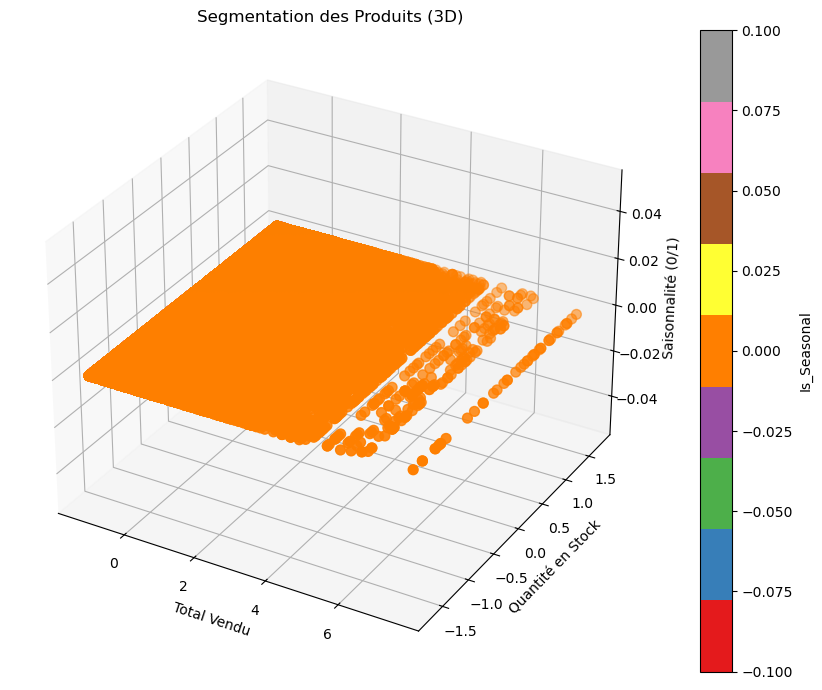

In [37]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = merged_data['Total_Sold']
y = merged_data['Product_Stored_Quantity']
z = merged_data['Is_Seasonal']

sc = ax.scatter(x, y, z, c=z, cmap='Set1', s=50)
ax.set_xlabel('Total Vendu')
ax.set_ylabel('Quantité en Stock')
ax.set_zlabel('Saisonnalité (0/1)')
ax.set_title('Segmentation des Produits (3D)')
plt.colorbar(sc, label='Is_Seasonal')
plt.tight_layout()
plt.show()
